# Distributed CNOT for QAOA — gate teleportation vs PRISM cutting
### Two ways to run a circuit across QPUs, and why the partition matters for both

There are two paradigms for executing a cross-QPU gate:

* **Gate teleportation (entanglement-assisted).** A non-local CNOT can be done *exactly* with one shared
  Bell pair (**1 ebit**) + 2 classical bits, via the cat-entangler/cat-disentangler protocol. No
  reconstruction error — but it consumes inter-QPU entanglement.
* **Circuit cutting (PRISM / QPD).** Drop the cross gate and reconstruct classically — no entanglement, but
  an approximation (or a QPD sampling overhead γ).

We **implement and verify** the distributed CNOT, build an **exact distributed QAOA** from it, and then show
the punchline: the resource for the *exact* paradigm is the number of cross gates (= ebits), which is exactly
what a good PRISM partition minimises — so **PRISM helps both paradigms at once**, fewest ebits for exact
execution and best fidelity for classical cutting.

In [2]:
# ── Setup ──
%matplotlib inline
import sys, os, json, math, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
for cand in ['../src', 'src', '.']:
    if os.path.isdir(os.path.join(cand, 'prism')):
        sys.path.insert(0, os.path.abspath(cand)); break
import prism
from prism import distributed as dist
from prism import METHOD_COLOURS, METHOD_ORDER

RESULTS = 'results'; os.makedirs(RESULTS, exist_ok=True)
SCALE = os.environ.get('PRISM_SCALE', 'small')
CFG = {'small': dict(conv_ns=[4, 6], shots=[1000, 4000, 16000], cmp_ns=[8, 10], seeds=[19, 23],
                     cmp_methods=METHOD_ORDER),
       'full':  dict(conv_ns=[4, 6, 8], shots=[1000, 4000, 16000, 64000], cmp_ns=[8, 10, 12, 14],
                     seeds=[19, 23, 29, 31], cmp_methods=METHOD_ORDER)}[SCALE]
RECOMPUTE = os.environ.get('PRISM_RECOMPUTE', '0') == '1'

def cache_or_compute(path, fn, kind='csv', force=None):
    force = RECOMPUTE if force is None else force
    if (not force) and os.path.exists(path):
        return pd.read_csv(path) if kind == 'csv' else json.load(open(path))
    obj = fn()
    if kind == 'csv':
        obj.to_csv(path, index=False)
    else:
        json.dump(obj, open(path, 'w'))
    return obj

def fidelity(p, q):
    return float(np.sum(np.sqrt(np.clip(p, 0, None) * np.clip(q, 0, None))))

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
                     'font.size': 9.5, 'axes.titleweight': 'bold', 'axes.grid': True, 'grid.alpha': 0.3})
print('prism', prism.__version__, '| scale', SCALE)

prism 0.1.0 | scale small


In [3]:
import random, networkx as nx
from prism import qml

def community_maxcut(n, seed, p_in=0.75, p_out=0.15):
    # two clusters of n/2 nodes (dense within, sparse between) ~ two natural QPUs,
    # with a hidden relabelling so the naive half-split does NOT align with them.
    rng = random.Random(seed); h = n // 2
    g = nx.Graph(); g.add_nodes_from(range(n))
    for i in range(n):
        for j in range(i + 1, n):
            same = (i < h) == (j < h)
            if rng.random() < (p_in if same else p_out):
                g.add_edge(i, j, weight=1.0)
    if g.number_of_edges() == 0:
        g.add_edge(0, h)
    perm = list(range(n)); rng.shuffle(perm)
    return nx.relabel_nodes(g, {i: perm[i] for i in range(n)})

def community_qaoa_layout(n, seed, maxiter=40):
    g = community_maxcut(n, seed)
    r = qml.optimize_qaoa(g, n, p=1, optimizer='COBYLA', seed=seed, maxiter=maxiter)
    return qml.maxcut_qaoa_layout(g, *qml.qaoa_split_params(r['x']))

def compute_verify():
    ok, tvd = dist.verify_nonlocal_cnot(shots=16000)
    return {'ok': bool(ok), 'max_tvd': float(tvd)}

def compute_convergence():
    rows = []
    for n in CFG['conv_ns']:
        layout = community_qaoa_layout(n, seed=19)
        qc, _ = prism.compile_circuit(layout, num_qubits=n)
        p_ideal = prism.prob_from_statevector(prism.get_statevector(qc))
        G = prism.build_interaction_graph(layout, n)
        A, B = prism.partition('PRISM-LCT', G, layout, n, qc_full=qc, seed=19)
        for shots in CFG['shots']:
            p_d, info = dist.distributed_sample_probs(layout, A, B, n, shots=shots, seed=1)
            tvd = 0.5 * float(np.sum(np.abs(p_ideal - p_d))) if p_d is not None else np.nan
            rows.append(dict(n=n, shots=shots, tvd=tvd, ebits=info['n_ebits']))
    return pd.DataFrame(rows)

def compute_comparison():
    rows = []
    for n in CFG['cmp_ns']:
        for seed in CFG['seeds']:
            layout = community_qaoa_layout(n, seed)
            qc, _ = prism.compile_circuit(layout, num_qubits=n, use_numeric_params=True)
            p_ideal = prism.prob_from_statevector(prism.get_statevector(qc))
            G = prism.build_interaction_graph(layout, n)
            res, _ = prism.run_all_partition_methods(G, layout, n, qc_full=qc, seed=seed,
                                                     methods=CFG['cmp_methods'])
            for m, (A, B, dt) in res.items():
                ebits = dist.count_cross_gates(layout, A, B)        # exact-teleport paradigm cost
                p_rec = prism.reconstruct_product(A, B, layout, n)   # cutting paradigm (classical)
                fid = fidelity(p_ideal, p_rec) if p_rec is not None else np.nan
                rows.append(dict(n=n, seed=seed, method=m, ebits=ebits, cbits=2 * ebits,
                                 recon_fidelity=fid))
    return pd.DataFrame(rows)

verify = cache_or_compute(f'{RESULTS}/nb10_verify.json', compute_verify, kind='json')
df_conv = cache_or_compute(f'{RESULTS}/nb10_convergence.csv', compute_convergence)
df_cmp  = cache_or_compute(f'{RESULTS}/nb10_comparison.csv', compute_comparison)
print(f"nonlocal CNOT verified == CNOT: {verify['ok']} (max TVD {verify['max_tvd']:.4f}, shot-limited)")
present = [m for m in METHOD_ORDER if m in set(df_cmp.method)]

nonlocal CNOT verified == CNOT: True (max TVD 0.0094, shot-limited)


## 1. The distributed CNOT protocol (implemented and verified)

One shared Bell pair turns two local CNOTs + two measurements + two classical bits into an exact non-local
CNOT. The circuit below is the actual protocol from `prism.distributed.nonlocal_cnot` (q0 = control on QPU A,
q1 = target on QPU B, q2/q3 = the ebit pair).

q0=control (QPU A), q1=target (QPU B), q2,q3 = shared Bell pair (the ebit); m = 2 classical bits.


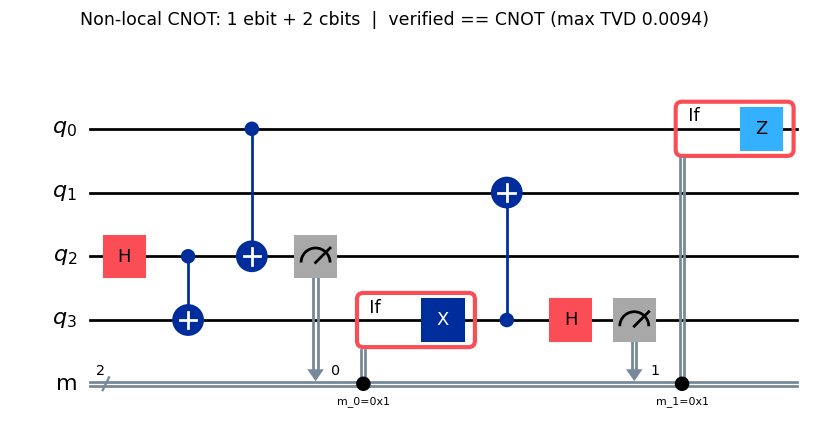

In [6]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
qr = QuantumRegister(4, 'q'); cm = ClassicalRegister(2, 'm')
proto = QuantumCircuit(qr, cm)
dist.nonlocal_cnot(proto, qr[0], qr[1], qr[2], qr[3], cm[0], cm[1], reset_ancillas=False)
try:
    f = proto.draw(output='mpl', fold=-1, scale=0.9)
    f.suptitle(f"Non-local CNOT: 1 ebit + 2 cbits  |  verified == CNOT (max TVD {verify['max_tvd']:.4f})", y=1.03)
    f.savefig(f'{RESULTS}/nb10_f01_protocol.png', bbox_inches='tight'); plt.show()
except Exception as e:
    print('draw skipped:', e)
print('q0=control (QPU A), q1=target (QPU B), q2,q3 = shared Bell pair (the ebit); m = 2 classical bits.')
f

## 3. The partition decides the cost of *both* paradigms

We now use **community-structured MaxCut graphs** — two dense clusters joined by a sparse interface, with the
cluster labels hidden by a random relabelling (so the naive half-split does *not* align with them). This is
the natural distributed scenario: two clusters ≈ two QPUs. For each partition method: **ebits** = cross gates
needed for exact teleported execution (lower is better), and **reconstruction fidelity** = quality of the
classical-cutting alternative (higher is better). A structure-aware cut finds the sparse interface — paying
few ebits *and* reconstructing faithfully — while the naive cut slices through both clusters.

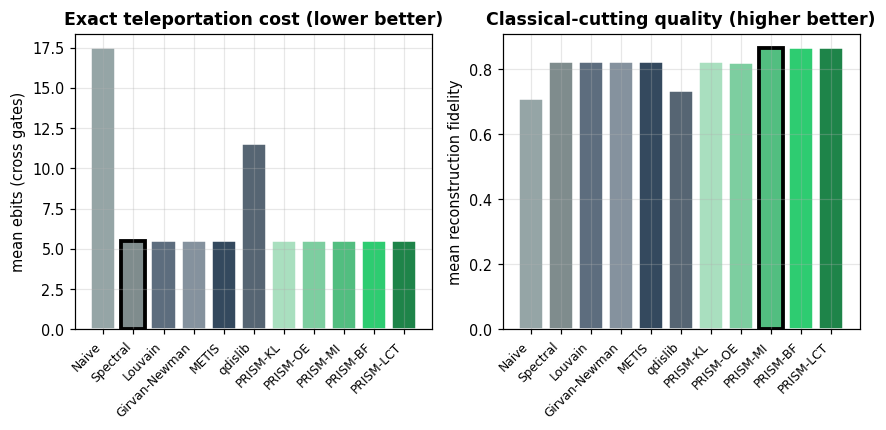

In [5]:
cols = [METHOD_COLOURS.get(m, '#333') for m in present]
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
eb = df_cmp.groupby('method').ebits.mean().reindex(present)
bars = ax[0].bar(range(len(present)), eb.values, color=cols, edgecolor='white')
ax[0].set_xticks(range(len(present))); ax[0].set_xticklabels(present, rotation=45, ha='right', fontsize=8)
ax[0].set_ylabel('mean ebits (cross gates)'); ax[0].set_title('Exact teleportation cost (lower better)')
bars[int(np.argmin(eb.values))].set_edgecolor('k'); bars[int(np.argmin(eb.values))].set_linewidth(2.5)
fd = df_cmp.groupby('method').recon_fidelity.mean().reindex(present)
bars = ax[1].bar(range(len(present)), fd.values, color=cols, edgecolor='white')
ax[1].set_xticks(range(len(present))); ax[1].set_xticklabels(present, rotation=45, ha='right', fontsize=8)
ax[1].set_ylabel('mean reconstruction fidelity'); ax[1].set_title('Classical-cutting quality (higher better)')
bars[int(np.nanargmax(fd.values))].set_edgecolor('k'); bars[int(np.nanargmax(fd.values))].set_linewidth(2.5)
fig.tight_layout(); fig.savefig(f'{RESULTS}/nb10_f03_paradigms.png'); plt.show()

## 5. Outputs

| file | content |
|---|---|
| `results/nb10_verify.json` | non-local CNOT verification (max TVD vs local CNOT) |
| `results/nb10_convergence.csv` | distributed-QAOA TVD vs shots (exactness check) |
| `results/nb10_comparison.csv` | per-(n, seed, method) ebits + classical-cutting fidelity |
| `results/nb10_f01..f04_*.png` | protocol circuit, convergence, paradigm bars, trade-off map |

The distributed primitives live in `prism.distributed` (`nonlocal_cnot`, `nonlocal_cz`,
`build_distributed_circuit`, `distributed_sample_probs`). `SCALE='full'` adds higher shot counts and n up to
14. The teleported execution is exact (LOCC + 1 ebit per cross gate); cutting trades that ebit for a
classical approximation.